# healpy 1.20.0b1 beta — `harmonic_ud_grade` for artifact-safe map downgrading

    pip install --pre healpy==1.20.0b1

`harmonic_ud_grade` changes map NSIDE through spherical-harmonic transforms
with pixel-window and beam transfer corrections following Eq. 1 of
[Planck 2015 X (arXiv:1502.01588)](https://arxiv.org/abs/1502.01588).

The two main modes are:

- `fwhm_out=0` (default): plain bandlimit truncation with pixel window correction
- `fwhm_out=None`: applies the effective resolution beam ($3 \times \theta_{\rm pix}$) to suppress Gibbs ringing

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

hp.disable_warnings()
print(f"healpy {hp.__version__}")

healpy 1.19.1.dev34+gb6c6692e5.d20260529


/tmp/ipykernel_2269582/3900260292.py:5: HealpyDeprecationWarning: The disable_warnings function is deprecated and may be removed in a future version.
  hp.disable_warnings()


In [2]:
nside_in = 512
nside_out = 64

np.random.seed(42)
m = hp.synfast(cls=np.arange(1, 1001)**(-2.5), nside=nside_in, lmax=3*nside_in-1, verbose=False)

/tmp/ipykernel_2269582/2046387934.py:5: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  m = hp.synfast(cls=np.arange(1, 1001)**(-2.5), nside=nside_in, lmax=3*nside_in-1, verbose=False)


## `fwhm_out=0` — bandlimit truncation only

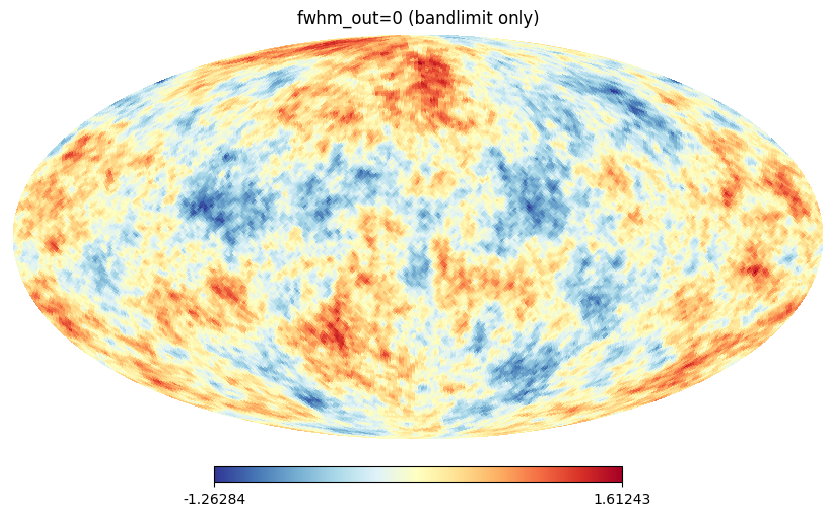

In [3]:
m_beam0 = hp.harmonic_ud_grade(m, nside_out, fwhm_out=0)
hp.mollview(m_beam0, title="fwhm_out=0 (bandlimit only)", cmap="RdYlBu_r")

## `fwhm_out=None` — effective resolution beam

Applies a Gaussian beam with FWHM = $3 \times \theta_{\rm pix}$ at the output NSIDE, following the Planck convention.

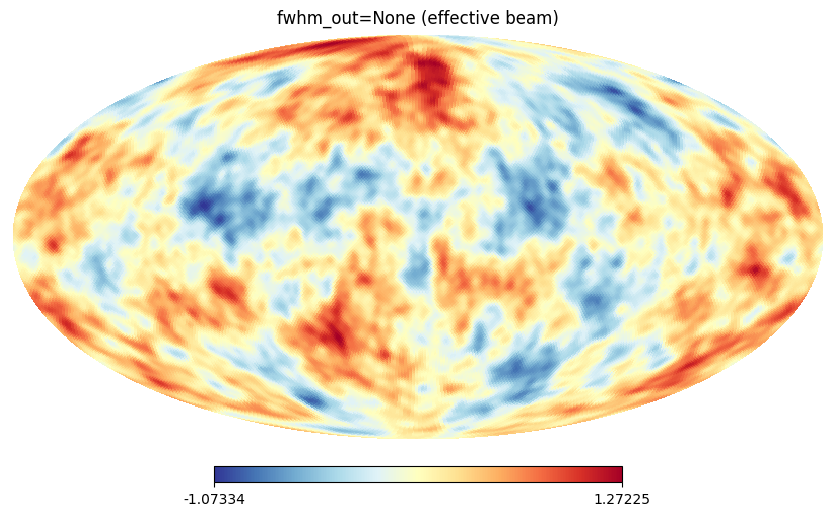

In [4]:
m_beam_auto = hp.harmonic_ud_grade(m, nside_out, fwhm_out=None)
hp.mollview(m_beam_auto, title="fwhm_out=None (effective beam)", cmap="RdYlBu_r")

## Power spectra

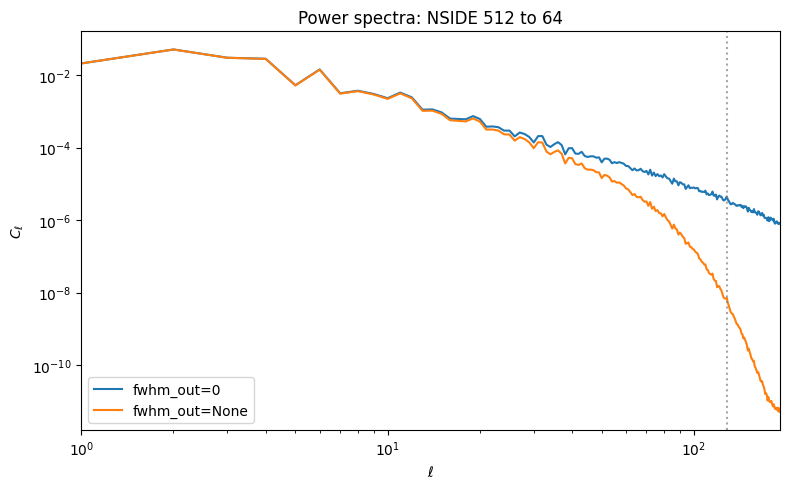

In [5]:
lmax_out = 3 * nside_out - 1
cl_beam0 = hp.anafast(m_beam0, lmax=lmax_out)
cl_beam_auto = hp.anafast(m_beam_auto, lmax=lmax_out)
ell = np.arange(lmax_out + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ell[1:], cl_beam0[1:], label="fwhm_out=0")
ax.loglog(ell[1:], cl_beam_auto[1:], label="fwhm_out=None")
ax.axvline(2 * nside_out, color="gray", ls=":", alpha=0.7)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$C_\ell$")
ax.set_title(f"Power spectra: NSIDE {nside_in} to {nside_out}")
ax.legend()
ax.set_xlim(1, lmax_out)
fig.tight_layout()

## Try it

- API docs: <https://healpy.readthedocs.io/en/latest/generated/healpy.sphtfunc.harmonic_ud_grade.html>
- Report issues: <https://github.com/healpy/healpy/issues>